In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn import metrics
import xgboost as xgb
import time
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

In [93]:
data = pd.read_csv("data_3_values_by_day.csv")
data

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
0,2022-01-28 00:00:00,64.767911,10.011742,120.091735,555.430570,15.255906
1,2022-01-28 08:00:00,64.193674,10.009246,120.023860,550.337705,22.246696
2,2022-01-28 16:00:00,63.912885,9.708684,114.701485,547.888626,25.059102
3,2022-01-29 00:00:00,63.892667,9.382377,108.993462,548.397254,23.607689
4,2022-01-29 08:00:00,63.030948,9.503467,109.672496,540.445674,20.491361
...,...,...,...,...,...,...
212,2022-10-19 08:00:00,59.034442,9.738259,103.756132,506.144457,19.743052
213,2022-10-19 16:00:00,58.196467,9.514840,108.719497,498.817430,19.743052
214,2022-10-20 00:00:00,58.120637,9.477183,109.858441,498.298019,19.743052
215,2022-10-20 08:00:00,56.303701,9.846997,101.390345,483.159073,19.743052


<AxesSubplot:>

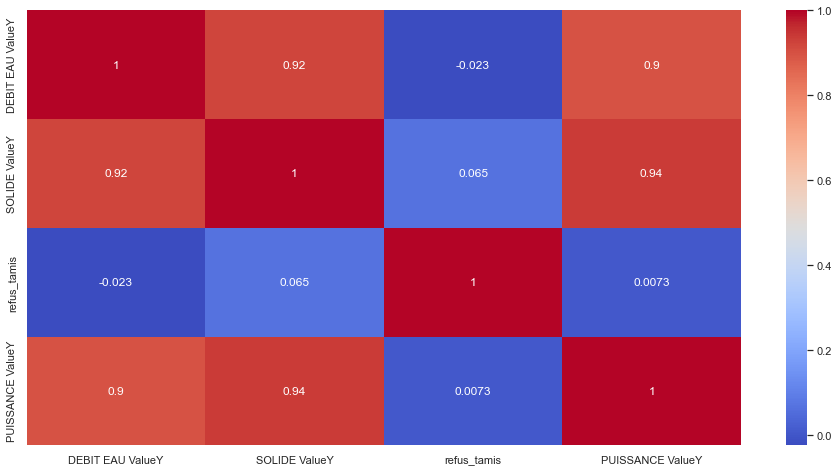

In [94]:
df = data[["DEBIT EAU ValueY","SOLIDE ValueY","refus_tamis","PUISSANCE ValueY"]]
sns.set(rc = {'figure.figsize':(16,8)})
sns.heatmap(df.corr(), annot = True, fmt='.2g',cmap= 'coolwarm')

c:\Users\Amine DD\AppData\Local\Programs\Python\Python38\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='refus_tamis', ylabel='Density'>

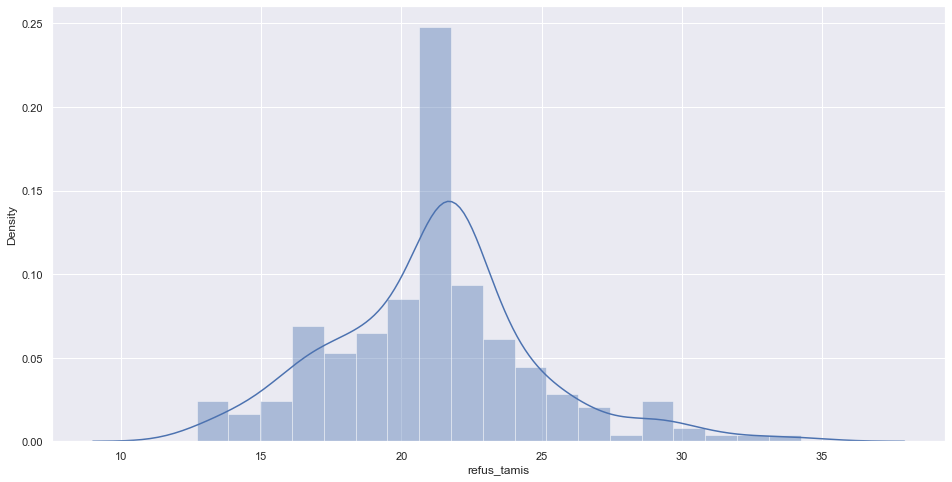

In [95]:
plt.figure()
sns.distplot(data["refus_tamis"])

In [96]:
data['Time'] = pd.to_datetime(data['Time'], format="%Y/%m/%d %H:%M:%S")
data.dtypes

Time                datetime64[ns]
COURANT ValueY             float64
DEBIT EAU ValueY           float64
SOLIDE ValueY              float64
PUISSANCE ValueY           float64
refus_tamis                float64
dtype: object

In [97]:
X = data[["Time","DEBIT EAU ValueY","SOLIDE ValueY","PUISSANCE ValueY"]]
X

,Time,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY
0,2022-01-28 00:00:00,10.011742,120.091735,555.430570
1,2022-01-28 08:00:00,10.009246,120.023860,550.337705
2,2022-01-28 16:00:00,9.708684,114.701485,547.888626
3,2022-01-29 00:00:00,9.382377,108.993462,548.397254
4,2022-01-29 08:00:00,9.503467,109.672496,540.445674
...,...,...,...,...
212,2022-10-19 08:00:00,9.738259,103.756132,506.144457
213,2022-10-19 16:00:00,9.514840,108.719497,498.817430
214,2022-10-20 00:00:00,9.477183,109.858441,498.298019
215,2022-10-20 08:00:00,9.846997,101.390345,483.159073


In [98]:
y = data[["Time","refus_tamis"]]
y

,Time,refus_tamis
0,2022-01-28 00:00:00,15.255906
1,2022-01-28 08:00:00,22.246696
2,2022-01-28 16:00:00,25.059102
3,2022-01-29 00:00:00,23.607689
4,2022-01-29 08:00:00,20.491361
...,...,...
212,2022-10-19 08:00:00,19.743052
213,2022-10-19 16:00:00,19.743052
214,2022-10-20 00:00:00,19.743052
215,2022-10-20 08:00:00,19.743052


In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [100]:
X_train

,Time,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY
82,2022-09-06 00:00:00,11.512134,115.018881,569.320451
65,2022-08-31 08:00:00,10.561809,102.983389,580.000523
109,2022-09-15 00:00:00,12.031878,115.002481,545.690106
183,2022-10-09 16:00:00,13.337231,131.968638,534.924711
31,2022-02-14 08:00:00,10.006251,114.980410,574.789978
...,...,...,...,...
106,2022-09-14 00:00:00,12.005853,115.000519,548.572819
14,2022-02-01 16:00:00,9.700140,113.742497,546.713821
92,2022-09-09 08:00:00,11.991891,114.710970,585.438340
179,2022-10-08 08:00:00,12.165737,120.520618,491.990814


In [101]:
y_train

,Time,refus_tamis
82,2022-09-06 00:00:00,16.764081
65,2022-08-31 08:00:00,19.498698
109,2022-09-15 00:00:00,21.667322
183,2022-10-09 16:00:00,18.136087
31,2022-02-14 08:00:00,28.748327
...,...,...
106,2022-09-14 00:00:00,21.620746
14,2022-02-01 16:00:00,29.126214
92,2022-09-09 08:00:00,13.792304
179,2022-10-08 08:00:00,23.819349


In [102]:
(X_train.isna().sum()/X_train.shape[0]).sort_values(ascending=True)

Time                0.000000
PUISSANCE ValueY    0.000000
DEBIT EAU ValueY    0.013245
SOLIDE ValueY       0.026490
dtype: float64

In [103]:
X_train_1 = X_train[["DEBIT EAU ValueY","SOLIDE ValueY","PUISSANCE ValueY"]]
X_test_1 = X_test[["DEBIT EAU ValueY","SOLIDE ValueY","PUISSANCE ValueY"]]
y_train_1 = y_train[["refus_tamis"]]
y_test_1 = y_test[["refus_tamis"]]

Remplacer les NaNs par le moyen 

In [104]:
imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
X_train_1 = pd.DataFrame(imputer.fit_transform(X_train_1), columns=["DEBIT EAU ValueY","SOLIDE ValueY","PUISSANCE ValueY"],index=X_train_1.index)
X_train_1

,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY
82,11.512134,115.018881,569.320451
65,10.561809,102.983389,580.000523
109,12.031878,115.002481,545.690106
183,13.337231,131.968638,534.924711
31,10.006251,114.980410,574.789978
...,...,...,...
106,12.005853,115.000519,548.572819
14,9.700140,113.742497,546.713821
92,11.991891,114.710970,585.438340
179,12.165737,120.520618,491.990814


In [105]:
(X_train_1.isna().sum()/X_train_1.shape[0]).sort_values(ascending=True)

DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
PUISSANCE ValueY    0.0
dtype: float64

In [106]:
X_test_1 = pd.DataFrame(imputer.transform(X_test_1), columns=["DEBIT EAU ValueY","SOLIDE ValueY","PUISSANCE ValueY"],index=X_test_1.index)
X_test_1

,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY
205,9.583560,109.814155,494.770667
214,9.477183,109.858441,498.298019
138,10.973148,113.113202,562.548328
177,12.278148,142.623755,519.955264
15,9.988294,115.011075,541.726126
...,...,...,...
5,9.847241,113.136079,534.290683
136,9.997539,109.237697,541.967980
56,13.168845,127.373739,576.337919
100,11.990803,115.014313,551.246553


In [107]:
(X_test_1.isna().sum()/X_test_1.shape[0]).sort_values(ascending=True)

DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
PUISSANCE ValueY    0.0
dtype: float64

KNN Regression
XGBoost

KNN Regression

In [111]:
Start_Time = time.time()
knn_model = KNeighborsRegressor(n_neighbors=3).fit(X_train_1, y_train_1)
Execution_Time_knn = time.time() - Start_Time
score_knn_train = knn_model.score(X_train_1, y_train_1)
score_knn_train

0.45450461387686936

In [113]:
score_knn_test = knn_model.score(X_test_1, y_test_1)
score_knn_test

-0.18800563185839025

XGBoost

In [114]:
model = xgb.XGBRegressor()
Start_Time = time.time()
model.fit(X_train_1, y_train_1)
Execution_Time_xgboost = time.time() - Start_Time
print(model)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=0, gpu_id=-1,
             grow_policy='depthwise', importance_type=None,
             interaction_constraints='', learning_rate=0.300000012, max_bin=256,
             max_cat_threshold=64, max_cat_to_onehot=4, max_delta_step=0,
             max_depth=6, max_leaves=0, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, ...)


In [115]:
model.score(X_train_1, y_train_1)

0.999976087141155

In [116]:
model.score(X_test_1, y_test_1)

-0.15088632483607012

Evaluation par RMSE de ces 4 algorithme

In [117]:
print("KNN Regression: ", np.sqrt(metrics.mean_squared_error(y_test_1,knn_model.predict(X_test_1))))
print("XGBoost Regression: ", np.sqrt(metrics.mean_squared_error(y_test_1,model.predict(X_test_1))))

KNN Regression:  3.8260713618513766
XGBoost Regression:  3.76582410568739


prediction for the test sample

In [118]:
##############################################################
Start_time = time.time()
y_predict_dep_test_knn = knn_model.predict(X_test_1)
knn_pred_time = time.time() - Start_time
##############################################################
Start_time = time.time()
y_predict_dep_test_xgboost = model.predict(X_test_1)
xgboost_pred_time = time.time() - Start_time

Compare the performance of models

In [119]:
pd.DataFrame({'MSE':[metrics.mean_squared_error(y_test_1,knn_model.predict(X_test_1)),metrics.mean_squared_error(y_test_1,model.predict(X_test_1))],
              'MAE': [metrics.mean_absolute_error(y_test_1,knn_model.predict(X_test_1)),metrics.mean_absolute_error(y_test_1,model.predict(X_test_1))],
              'Time of Execution train (s)':[Execution_Time_knn,Execution_Time_xgboost],
              'Time of prediction test (s)':[knn_pred_time,xgboost_pred_time]}, index=["KNN","XGBoost"])

,MSE,MAE,Time of Execution train (s),Time of prediction test (s)
KNN,14.638822,2.524466,0.000000,0.00496
XGBoost,14.181431,2.580075,0.119124,0.00000


Evaluate the model with dep_test sample and plot the result

In [120]:
print(f"The mean : {y_test_1.mean()}")
print(f"The median : {y_test_1.median()}")
print(f"The variance : {y_test_1.var()}")

The mean : refus_tamis    21.032247
dtype: float64
The median : refus_tamis    21.667322
dtype: float64
The variance : refus_tamis    12.511754
dtype: float64


In [121]:
y_predict_dep_test_knn = knn_model.predict(X_test_1)
y_predict_dep_test_xgboost = model.predict(X_test_1)

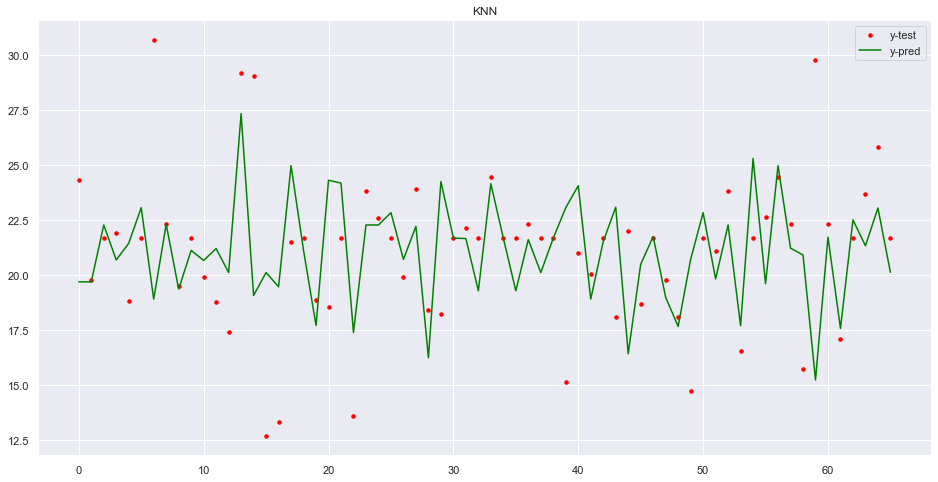

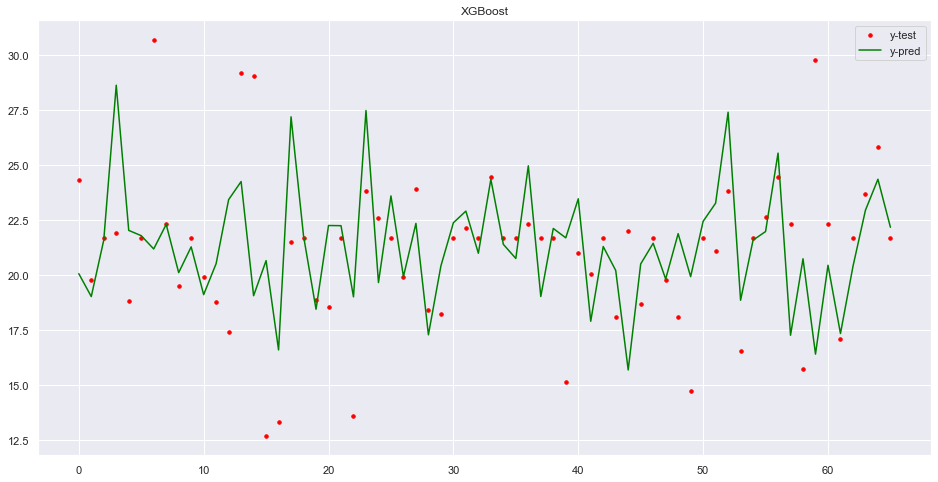

In [122]:
list_prediction = [y_predict_dep_test_knn,y_predict_dep_test_xgboost]
list_alg = ["KNN","XGBoost"]
for pred,alg in zip(list_prediction,list_alg):
    x_ax = range(len(X_test_1))
    plt.scatter(x_ax, y_test_1,  s=12, label="y-test",c= "red")
    plt.plot(x_ax, pred, label="y-pred",c = "green")
    plt.legend()
    plt.title(alg)
    plt.show()

Comparaison Réelle & Prediction pour le deployement sample

In [123]:
prediction = pd.DataFrame(list(zip(y_test_1["refus_tamis"],knn_model.predict(X_test_1).T.tolist()[0],model.predict(X_test_1).T.tolist())), columns = ['RefusTamis Réelle','Prediction KNN','Prediction XGBoost'])
prediction

,RefusTamis Réelle,Prediction KNN,Prediction XGBoost
0,24.295011,19.678697,20.051615
1,19.743052,19.678697,19.010202
2,21.667322,22.263232,21.574055
3,21.879815,20.672849,28.616468
4,18.786127,21.431548,22.017538
...,...,...,...
61,17.101865,17.560413,17.330448
62,21.667322,22.494141,20.379429
63,23.686665,21.318898,22.934328
64,25.819419,23.035829,24.341337


In [124]:
prediction.to_excel("prediction_refus_tamis.xlsx")

Use this predict to augment refus_tamis feature in the 1 value per minute scale

In [170]:
data_2 = pd.read_csv("data.csv")
data_2

,Time,COURANT ValueY,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY,refus_tamis
0,2022-01-28 00:00:00,67.253113,10.185185,121.003326,576.604736,20.849820
1,2022-01-28 00:01:00,67.253113,10.185185,121.003326,576.604736,20.849820
2,2022-01-28 00:02:00,67.253113,10.185185,121.003326,576.604736,20.849820
3,2022-01-28 00:03:00,67.253113,10.185185,121.003326,576.604736,20.849820
4,2022-01-28 00:04:00,67.253113,10.185185,121.003326,576.604736,20.849820
...,...,...,...,...,...,...
101066,2022-10-20 16:57:00,NaN,NaN,NaN,507.211636,19.755739
101067,2022-10-20 16:58:00,NaN,NaN,NaN,511.160186,19.755739
101068,2022-10-20 16:59:00,NaN,NaN,NaN,509.005283,19.755739
101069,2022-10-20 17:00:00,NaN,NaN,NaN,510.360491,19.755739


In [171]:
data_2['Time'] = pd.to_datetime(data_2['Time'], format="%Y/%m/%d %H:%M:%S")
data_2.dtypes

Time                datetime64[ns]
COURANT ValueY             float64
DEBIT EAU ValueY           float64
SOLIDE ValueY              float64
PUISSANCE ValueY           float64
refus_tamis                float64
dtype: object

In [174]:
data_2_X = data_2[["DEBIT EAU ValueY","SOLIDE ValueY","PUISSANCE ValueY"]]
data_2_X

,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY
0,10.185185,121.003326,576.604736
1,10.185185,121.003326,576.604736
2,10.185185,121.003326,576.604736
3,10.185185,121.003326,576.604736
4,10.185185,121.003326,576.604736
...,...,...,...
101066,NaN,NaN,507.211636
101067,NaN,NaN,511.160186
101068,NaN,NaN,509.005283
101069,NaN,NaN,510.360491


In [177]:
(data_2_X.isna().sum()/data_2_X.shape[0]).sort_values(ascending=True)

PUISSANCE ValueY    0.000000
DEBIT EAU ValueY    0.002820
SOLIDE ValueY       0.011606
dtype: float64

In [178]:
imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
data_2_X = pd.DataFrame(imputer.fit_transform(data_2_X), columns=["DEBIT EAU ValueY","SOLIDE ValueY","PUISSANCE ValueY"],index=data_2_X.index)
data_2_X

,DEBIT EAU ValueY,SOLIDE ValueY,PUISSANCE ValueY
0,10.185185,121.003326,576.604736
1,10.185185,121.003326,576.604736
2,10.185185,121.003326,576.604736
3,10.185185,121.003326,576.604736
4,10.185185,121.003326,576.604736
...,...,...,...
101066,10.256077,106.631118,507.211636
101067,10.256077,106.631118,511.160186
101068,10.256077,106.631118,509.005283
101069,10.256077,106.631118,510.360491


In [179]:
(data_2_X.isna().sum()/data_2_X.shape[0]).sort_values(ascending=True)

DEBIT EAU ValueY    0.0
SOLIDE ValueY       0.0
PUISSANCE ValueY    0.0
dtype: float64

In [180]:
prediction_data_value_per_minute = knn_model.predict(data_2_X)

In [184]:
data_2_X = data_2_X.assign(refus_tamis = prediction_data_value_per_minute.T.tolist()[0])

In [186]:
data_2_X.to_csv("data_with_predicted_refus_tamis.csv",index=False)